# SimFL — Practical Federated Gradient Boosting Decision Trees

Implementation of **Li, Wen & He, "Practical Federated Gradient Boosting Decision Trees", AAAI 2020**
([arXiv:1911.04206](https://arxiv.org/abs/1911.04206)) for intrusion detection on the two datasets in this repository.

**Setting.** Horizontal federated learning: `M` parties hold different samples with the same features.
All parties run in one process. Every byte one party learns about another goes through the `Communicator`,
which counts rounds and bytes. Party data lives in private attributes of `Party` objects, and the
orchestration code only calls party methods.

**SimFL has two stages:**

1. **Preprocessing (LSH).** All parties generate the same `L` p-stable hash functions
   `h(x) = floor((a·x + b) / r)` from a shared seed. Each party hashes its own samples and shares only hash values and
   sample IDs. For each of its samples, a party then finds, at every other party, the sample with the most
   identical hash values (its *similar instance*).
2. **Training (Weighted Gradient Boosting, WGB).** Parties take turns building trees. When party `m` builds a tree,
   every other party `j` sums the gradients (and Hessians) of its own samples, grouped by their similar instance in `m`,
   and sends only those sums. Party `m` then grows a tree on **its own samples only**, using
   *weighted* gradients `G_q = g_q + Σ_{j≠m} Σ_{i∈j: sim_m(i)=q} g_i` (same for `H`). The tree is broadcast and
   every party updates its predictions.

The notebook sections are: configuration → data → partitioning → communicator → LSH → WGB engine → baselines (SOLO, ALL-IN)
→ metrics → sanity checks → experiment grid → results.

## Implementation choices: where the paper is ambiguous or conflicts with the instructions

**Source caveat.** The network policy of the environment that built this notebook blocked arXiv, ar5iv, AAAI and every
other mirror of the paper's text, so the paper itself could not be re-read. Details were checked against the
**authors' official code** instead ([Xtra-Computing/SimFL](https://github.com/Xtra-Computing/SimFL), the code the paper links to),
and the notes below say which source each choice comes from.

| # | Topic | Paper / official code | Choice made here | Why |
|---|---|---|---|---|
| 1 | p-stable distribution for `a` | Paper: generic p-stable LSH. Official code: `p_norm=1` (**Cauchy**). | **Gaussian** (2-stable). `cauchy` is available via `CONFIG["lsh"]["p_stable"]`. | Your instruction; Gaussian ↔ Euclidean distance on standardized features. |
| 2 | Feature normalization before hashing | Not done in the paper's code (it hashes raw libsvm features). | **Z-score** with a *federated* scaler: parties exchange `(n, mean, M2)` per feature and combine them (Chan et al.), which is exactly the scaler fitted on the pooled **training** data. | Your instruction. Each party cannot see others' data, and per-party scalers would hash the same point differently. This costs **one extra preprocessing round**, counted separately from the hash exchange. Trees still use raw features. |
| 3 | `L`, `r` defaults | Official code: `L=40` tables, `r=4.0`. As I recall, the paper says `L = min(40, d−1)`. | `L = min(40, d−1)` (= 40 for both datasets, `d = 76…78`) and `r = 4.0`, both configurable. | The two readings agree on these datasets. |
| 4 | Tie-breaking among equally similar samples | Paper: I don't recall a rule and could not verify. Official code: lowest global ID (`thrust::max_element` on sorted IDs). | **Uniform random among the tied samples** (seeded); `"lowest_id"` is also available. | Your instruction for the unspecified case. Lowest ID would systematically bias the gradient mass toward early rows. |
| 5 | Samples with no hash collision at all | Official code prints an error and leaves the ID at its default `0`, which silently maps the sample to instance 0. | That sample's gradient is **not transferred** to that party for that tree. The count is logged (`simfl.unmatched_samples`). | Avoids the spurious mapping. It is rare: in the full grid, at most ~1 sample per run on average (10 parties), out of thousands. |
| 6 | Hash buckets | Official histogram path stores `hash % n_bucket` (500). | Raw hash values, no modulo. | The paper's `h(x)` has no modulo, which only adds false collisions. |
| 7 | Which party builds which tree | Official code has two schedules. Its README entrypoint gives each party a **contiguous block of trees proportional to its sample count** (`T·n_m/N`, party 0 first). The exact-split path uses strict round robin. | `"proportional_blocks"` by default; `"round_robin"` is available. | Follows the runnable entrypoint the authors ship. |
| 8 | What is aggregated | WGB needs weighted **gradients and Hessians** for both split gain and leaf values; the official code sums both. | Both are summed (your text said "gradients"). | Required by the leaf weight `−G/(H+λ)`. |
| 9 | Loss | Paper: generic differentiable loss. Official code: squared error on {0,1} labels with a 0.5 threshold. | **Logistic** (binary) and **softmax** (multi-class), with the same gradient/Hessian definitions as XGBoost's `binary:logistic` / `multi:softprob` (Hessian `2p(1−p)` for softmax). | Lets ALL-IN be plain XGBoost and keeps SimFL comparable to it exactly (checked below: SimFL with 1 party ≡ ALL-IN). |
| 10 | Multi-class | Not in the paper. | Each sample has a K-vector of gradients and Hessians; the K-vectors are summed per similar instance. One boosting round = one communication round = K trees. | Your instruction. |
| 11 | GBDT hyperparameters | Official code: 50 trees, depth 8, η=0.1, λ=1, γ=1, min_child_weight=1, 256 bins. Its histogram path never calls `shrink`, so η is effectively 1 there. | 50 rounds, depth 8, **η=0.1**, λ=1, γ=1, min_child_weight=1, 256 bins, for every method. | Treats the missing shrinkage as an oversight; η=0.1 is the value the code sets. |
| 12 | Split candidates | Official code: 256 equal-width bins over the **global** min/max of every party, which leaks feature ranges. | XGBoost `hist` quantile sketch of the **builder's own** data. | No extra information leaves a party. |
| 13 | XGBoost custom objective | You suggested a custom objective plus `base_margin`. | Custom objective that returns the precomputed weighted `(G, H)`, one round per `xgb.train` call, with `base_score=0`. The global model is an ordered list of one-round boosters whose margins are summed. **`base_margin` is not set:** tree growth depends only on `(G, H, X)`, and `base_margin` only changes the `preds` argument, which this objective ignores. For model size and inference timing, the list is merged into a single booster. | Faithful to WGB: checked below that per-round custom-objective training reproduces built-in XGBoost, and that the merged booster equals the summed list. A NumPy GBDT was therefore unnecessary. |
| 14 | Non-IID partitions | Paper: its own unbalanced splits. | Dirichlet label split (α ∈ {0.1, 0.5, 1.0}), re-drawn until every party has ≥ `min_party_size` samples. | Your instruction; empty parties cannot train. |
| 15 | Data | Not specified. | IoT: `Src_IP`/`Dst_IP` identifiers dropped (configurable). CICIDS class names follow the LabelEncoder order of this CICIDS2017 sample (0 = BENIGN). One fixed stratified 80/20 split (`split_seed=42`). Seeds vary partitions, LSH functions, tie-breaks and the XGBoost seed. | Keeps the centralized test set identical across every run. |

**Timing note.** Parties run sequentially in one process. Phase times are therefore *summed over all parties*, not the
parallel critical path. Communication is accounted separately as an *estimated* network time.

## 1. Configuration

In [1]:
CONFIG = {
    "datasets": {
        "CICIDS2017": {
            "path": "CICIDS2017_sample_km.csv", "label_col": "Label", "benign_label": 0, "drop_cols": [],
            # LabelEncoder order of the CICIDS2017 k-means sample (alphabetical): 0 is BENIGN
            "class_names": {0: "BENIGN", 1: "Bot", 2: "BruteForce", 3: "DoS", 4: "Infiltration",
                            5: "PortScan", 6: "WebAttack"},
        },
        "IoT": {
            "path": "IoT_Network_Intrusion_Dataset_0.1.csv", "label_col": "Label", "benign_label": "Normal",
            "drop_cols": ["Src_IP", "Dst_IP"], "class_names": None,
        },
    },
    "modes": ["binary", "multiclass"],
    "partitions": ["iid", "dirichlet"],
    "dirichlet_alphas": [0.1, 0.5, 1.0],
    "n_parties": [2, 5, 10],
    "seeds": [0, 1, 2, 3, 4],
    "test_size": 0.20,
    "split_seed": 42,
    "min_party_size": 20,
    "lsh": {"L": None, "max_L": 40, "r": 4.0, "p_stable": "gaussian", "tie_break": "random"},  # L=None -> min(40, d-1)
    "schedule": "proportional_blocks",          # or "round_robin"
    "gbdt": {"n_rounds": 50, "max_depth": 8, "eta": 0.1, "reg_lambda": 1.0, "gamma": 1.0,
             "min_child_weight": 1.0, "max_bin": 256, "tree_method": "hist"},
    "n_threads": 4,
    "network": {"latency_ms": 20.0, "bandwidth_mbps": 100.0},
    "inference": {"n_single": 1000, "n_warmup": 100},
    "methods": ["SimFL", "SOLO", "ALL-IN"],
    "results_dir": "results/simfl",
    "resume": True,              # skip runs whose JSON already exists
    "smoke_test": False,         # True: tiny grid for a quick end-to-end check
}

if CONFIG["smoke_test"]:
    CONFIG.update(seeds=[0], n_parties=[2], dirichlet_alphas=[0.5], results_dir="results/simfl_smoke")
    CONFIG["gbdt"]["n_rounds"] = 5
    CONFIG["inference"].update(n_single=50, n_warmup=5)

import os
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ[_v] = str(CONFIG["n_threads"])   # must be set before numpy / xgboost are imported

In [2]:
import copy, json, platform, time, warnings
from collections import defaultdict
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
import sklearn
import xgboost as xgb
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_recall_fscore_support)
from sklearn.model_selection import StratifiedKFold, train_test_split

warnings.filterwarnings("ignore", message="The least populated class")
ENV = {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
       "scipy": scipy.__version__, "sklearn": sklearn.__version__, "xgboost": xgb.__version__,
       "platform": platform.platform(), "n_threads": CONFIG["n_threads"]}
print(ENV)

{'python': '3.11.15', 'numpy': '2.4.6', 'pandas': '3.0.6', 'scipy': '1.17.1', 'sklearn': '1.9.1', 'xgboost': '3.2.0', 'platform': 'Linux-6.18.44-fc-v70-x86_64-with-glibc2.39', 'n_threads': 4}


## 2. Data

Classes are re-indexed so the benign class is always index 0, followed by the attack classes in sorted order.
**Binary mode** maps 0 → benign and every attack → 1. The held-out test set is centralized and stratified on the multi-class label.

In [3]:
def load_dataset(name, spec):
    df = pd.read_csv(spec["path"], low_memory=False)
    df = df.drop(columns=[c for c in spec["drop_cols"] if c in df.columns])
    y_raw = df.pop(spec["label_col"])
    X = df.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    n_bad = int(X.isna().sum().sum())
    X = X.fillna(0.0)
    others = sorted(c for c in y_raw.unique() if c != spec["benign_label"])
    classes = [spec["benign_label"]] + others
    y = y_raw.map({c: i for i, c in enumerate(classes)}).to_numpy(np.int64)
    names = [str(spec["class_names"][c]) if spec["class_names"] else str(c) for c in classes]
    return {"name": name, "X": X.to_numpy(np.float32), "y": y, "class_names": names,
            "feature_names": list(X.columns), "n_bad_values": n_bad}


def split_dataset(ds, cfg):
    idx_tr, idx_te = train_test_split(np.arange(len(ds["y"])), test_size=cfg["test_size"],
                                      random_state=cfg["split_seed"], stratify=ds["y"])
    return {**ds, "X_train": ds["X"][idx_tr], "y_train": ds["y"][idx_tr],
            "X_test": ds["X"][idx_te], "y_test": ds["y"][idx_te]}


def labels_for_mode(y, mode):
    return (y != 0).astype(np.int64) if mode == "binary" else y


def class_names_for_mode(ds, mode):
    return ["benign", "attack"] if mode == "binary" else ds["class_names"]


DATA = {}
for _name, _spec in CONFIG["datasets"].items():
    DATA[_name] = split_dataset(load_dataset(_name, _spec), CONFIG)
    _d = DATA[_name]
    print(f"{_name}: X={_d['X'].shape}, train={len(_d['y_train'])}, test={len(_d['y_test'])}, "
          f"non-finite values replaced={_d['n_bad_values']}")
    print("   classes:", dict(zip(_d["class_names"], np.bincount(_d["y"]).tolist())))

CICIDS2017: X=(26800, 77), train=21440, test=5360, non-finite values replaced=0
   classes: {'BENIGN': 18225, 'Bot': 1966, 'BruteForce': 96, 'DoS': 3042, 'Infiltration': 36, 'PortScan': 1255, 'WebAttack': 2180}


IoT: X=(62578, 79), train=50062, test=12516, non-finite values replaced=0
   classes: {'Normal': 4031, 'DoS': 6047, 'MITM ARP Spoofing': 3540, 'Mirai': 41340, 'Scan': 7620}


## 3. Partitioning parties

* **IID**: `StratifiedKFold` folds, so each party has the global class mix (same scheme as the other notebooks in this repo).
* **Non-IID**: for each class, the proportions per party are drawn from `Dirichlet(α)`. The draw is repeated until every party
  holds at least `min_party_size` samples.

Partitions are built on the multi-class label, so binary and multi-class runs use exactly the same parties.

In [4]:
def iid_partition(y, n_parties, seed):
    if n_parties == 1:
        return [np.arange(len(y))]
    skf = StratifiedKFold(n_splits=n_parties, shuffle=True, random_state=seed)
    return [np.sort(test_idx) for _, test_idx in skf.split(np.zeros(len(y)), y)]


def dirichlet_partition(y, n_parties, alpha, seed, min_size, max_tries=10_000):
    rng = np.random.default_rng(seed)
    n_classes = int(y.max()) + 1
    for _ in range(max_tries):
        parts = [[] for _ in range(n_parties)]
        for c in range(n_classes):
            idx = rng.permutation(np.flatnonzero(y == c))
            props = rng.dirichlet(np.full(n_parties, alpha))
            cuts = (np.cumsum(props) * len(idx)).astype(int)[:-1]
            for p, chunk in enumerate(np.split(idx, cuts)):
                parts[p].extend(chunk.tolist())
        if min(len(p) for p in parts) >= min_size:
            return [np.sort(np.array(p, dtype=np.int64)) for p in parts]
    raise RuntimeError(f"no Dirichlet(alpha={alpha}) draw gave every party >= {min_size} samples")


def make_partition(y, kind, n_parties, seed, alpha, cfg):
    if kind == "iid":
        return iid_partition(y, n_parties, seed)
    return dirichlet_partition(y, n_parties, alpha, seed, cfg["min_party_size"])


def partition_label(kind, alpha):
    return "iid" if kind == "iid" else f"dirichlet_a{alpha}"

## 4. Communicator

All inter-party traffic goes through it. Each `send` deep-copies the payload into the receiver's mailbox, so the receiver
gets a copy, never a reference into the sender's memory. It also records the payload size: the exact `nbytes` of the arrays
and serialized models sent. A **round** is one synchronous exchange (parties → peer(s) → back). Rounds are opened explicitly
per phase and step, so preprocessing (scaler statistics, hash exchange) and training are counted separately.

In [5]:
def payload_nbytes(obj):
    if isinstance(obj, np.ndarray):
        return int(obj.nbytes)
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, (int, float, np.integer, np.floating)):
        return 8
    if isinstance(obj, dict):
        return sum(payload_nbytes(v) for v in obj.values())
    if isinstance(obj, (list, tuple)):
        return sum(payload_nbytes(v) for v in obj)
    raise TypeError(f"unsupported payload type {type(obj)}")


class Communicator:
    def __init__(self, n_parties):
        self.n_parties = n_parties
        self._mailbox = {p: [] for p in range(n_parties)}
        self.rounds = defaultdict(int)        # (phase, step) -> rounds
        self.bytes = defaultdict(int)         # (phase, tag)  -> bytes
        self.messages = 0
        self._phase = None

    def new_round(self, phase, step):
        self._phase = phase
        self.rounds[(phase, step)] += 1

    def send(self, src, dst, tag, payload):
        assert src != dst and self._phase is not None
        self.bytes[(self._phase, tag)] += payload_nbytes(payload)
        self.messages += 1
        self._mailbox[dst].append((src, tag, copy.deepcopy(payload)))

    def broadcast(self, src, tag, payload):
        for dst in range(self.n_parties):
            if dst != src:
                self.send(src, dst, tag, payload)

    def receive(self, dst, tag):
        mine = [(s, p) for s, t, p in self._mailbox[dst] if t == tag]
        self._mailbox[dst] = [m for m in self._mailbox[dst] if m[1] != tag]
        return sorted(mine, key=lambda m: m[0])

    def summary(self):
        r = lambda ph, st=None: sum(v for (p, s), v in self.rounds.items() if p == ph and (st is None or s == st))
        b = lambda ph, tg=None: sum(v for (p, t), v in self.bytes.items() if p == ph and (tg is None or t == tg))
        out = {
            "scaler_rounds": r("preprocessing", "scaler_stats"),
            "hash_exchange_rounds": r("preprocessing", "lsh_hashes"),
            "preprocessing_rounds": r("preprocessing"),
            "training_rounds": r("training"),
            "scaler_bytes": b("preprocessing", "scaler_stats"),
            "hash_exchange_bytes": b("preprocessing", "lsh_hashes"),
            "preprocessing_bytes": b("preprocessing"),
            "gradient_bytes": b("training", "aggregated_gradients"),
            "tree_bytes": b("training", "tree"),
            "training_bytes": b("training"),
            "messages": self.messages,
        }
        out["total_rounds"] = out["preprocessing_rounds"] + out["training_rounds"]
        out["total_bytes"] = out["preprocessing_bytes"] + out["training_bytes"]
        return out


class Timer:
    def __init__(self):
        self.t = defaultdict(float)

    @contextmanager
    def __call__(self, key):
        t0 = time.perf_counter()
        try:
            yield
        finally:
            self.t[key] += time.perf_counter() - t0

## 5. LSH preprocessing

`h_l(x) = floor((a_l·x + b_l) / r)` for `l = 1..L`, where `a_l` has i.i.d. Gaussian (2-stable) entries and `b_l ~ U[0, r)`.
All parties derive the same `(a, b)` from the shared seed.

For a query party `j` and target party `m`, the most similar instance of `x ∈ j` is `argmax_{y∈m} Σ_l 1[h_l(x)=h_l(y)]`.
Rows with identical signatures are de-duplicated. The match counts come from one sparse product of one-hot `(table, hash)`
indicators, processed in chunks. Ties are broken uniformly at random over the tied *samples*: a tied signature is chosen
with probability ∝ its multiplicity, then one of its members uniformly.

In [6]:
class PStableLSH:
    def __init__(self, n_features, L, r, seed, p_stable="gaussian"):
        rng = np.random.default_rng(seed)
        if p_stable == "gaussian":
            self.a = rng.standard_normal((n_features, L))
        elif p_stable == "cauchy":
            self.a = rng.standard_cauchy((n_features, L))
        else:
            raise ValueError(p_stable)
        self.b = rng.uniform(0.0, r, L)
        self.r = r

    def hash(self, Z):
        h = np.floor((Z @ self.a + self.b) / self.r)
        assert np.abs(h).max() < 2**31
        return h.astype(np.int32)


def most_similar(H_q, H_t, rng, tie_break="random", chunk=2048):
    """For every row of H_q, the index of the row of H_t sharing the most hash values (-1 if none share any)."""
    L = H_q.shape[1]
    Uq, inv_q = np.unique(H_q, axis=0, return_inverse=True)
    Ut, inv_t, cnt_t = np.unique(H_t, axis=0, return_inverse=True, return_counts=True)
    inv_q, inv_t = inv_q.ravel(), inv_t.ravel()
    cq, ct, off = [], [], 0
    for l in range(L):                                   # shared (table, hash value) column space
        vals, codes = np.unique(np.concatenate([Uq[:, l], Ut[:, l]]), return_inverse=True)
        cq.append(codes[:len(Uq)] + off); ct.append(codes[len(Uq):] + off); off += len(vals)
    cq, ct = np.stack(cq, 1), np.stack(ct, 1)
    onehot = lambda c, n: sp.csr_matrix((np.ones(c.size, np.int32), c.ravel(), np.arange(0, c.size + 1, L)), shape=(n, off))
    Aq, AtT = onehot(cq, len(Uq)), onehot(ct, len(Ut)).T.tocsr()

    order_t = np.argsort(inv_t, kind="stable")
    start_t = np.concatenate([[0], np.cumsum(cnt_t)])
    order_q = np.argsort(inv_q, kind="stable")
    start_q = np.concatenate([[0], np.cumsum(np.bincount(inv_q, minlength=len(Uq)))])
    min_id_t = np.array([order_t[start_t[s]:start_t[s + 1]].min() for s in range(len(Ut))])

    out = np.full(len(H_q), -1, np.int64)
    n_match = np.zeros(len(H_q), np.int32)
    for s in range(0, len(Uq), chunk):
        e = min(s + chunk, len(Uq))
        C = (Aq[s:e] @ AtT).toarray()                    # matching-hash counts, (unique queries, unique targets)
        mx = C.max(1)
        inst = order_q[start_q[s]:start_q[e]]            # query samples whose signature is in this chunk
        rows = inv_q[inst] - s
        tied = (C == mx[:, None]) & (mx[:, None] > 0)
        if tie_break == "lowest_id":
            sig = np.where(tied, min_id_t[None, :], np.iinfo(np.int64).max).argmin(1)[rows]
            member_id = min_id_t[sig]
        else:
            cw = np.cumsum(np.where(tied, cnt_t[None, :], 0), 1, dtype=np.float64)
            r = rng.random(len(inst)) * cw[rows, -1]
            sig = (cw[rows] > r[:, None]).argmax(1)
            k = np.minimum((rng.random(len(inst)) * cnt_t[sig]).astype(np.int64), cnt_t[sig] - 1)
            member_id = order_t[start_t[sig] + k]
        ok = mx[rows] > 0
        out[inst[ok]] = member_id[ok]
        n_match[inst] = mx[rows]
    return out, n_match


def combine_moments(stats):
    """Chan et al. parallel combination of per-party (n, mean, M2); returns global mean and std."""
    n, mean, m2 = 0, None, None
    for s in stats:
        nb, mb, m2b = s["n"], s["mean"].astype(np.float64), s["m2"].astype(np.float64)
        if n == 0:
            n, mean, m2 = nb, mb.copy(), m2b.copy()
            continue
        delta = mb - mean
        tot = n + nb
        mean = mean + delta * nb / tot
        m2 = m2 + m2b + delta**2 * n * nb / tot
        n = tot
    std = np.sqrt(m2 / n)
    return mean, np.where(std > 0, std, 1.0)

## 6. Weighted Gradient Boosting engine

Losses match XGBoost's built-in objectives. Binary: `g = p − y`, `h = max(p(1−p), 1e−16)`.
Softmax: `g_k = p_k − y_k`, `h_k = max(2p_k(1−p_k), 1e−16)`.

A `Party` holds its data privately and exposes only protocol steps. When it builds a tree, it calls `xgb.train` for **one** round
with a custom objective that returns the weighted `(G, H)`. The resulting one-round booster *is* the tree for that round
(K trees per round in multi-class). It is serialized and broadcast.

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def softmax(z):
    z = z - z.max(1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(1, keepdims=True)


def grad_hess(margin, y, mode, n_classes):
    if mode == "binary":
        p = sigmoid(margin)
        return p - y, np.maximum(p * (1.0 - p), 1e-16)
    p = softmax(margin)
    g = p.copy()
    g[np.arange(len(y)), y] -= 1.0
    return g, np.maximum(2.0 * p * (1.0 - p), 1e-16)


def xgb_params(cfg, mode, n_classes, seed, custom):
    g = cfg["gbdt"]
    p = {"tree_method": g["tree_method"], "max_depth": g["max_depth"], "eta": g["eta"],
         "reg_lambda": g["reg_lambda"], "gamma": g["gamma"], "min_child_weight": g["min_child_weight"],
         "max_bin": g["max_bin"], "nthread": cfg["n_threads"], "seed": seed, "verbosity": 0}
    if custom:          # margin starts at 0; objective supplied as precomputed (G, H)
        p.update(base_score=0.0, disable_default_eval_metric=1)
        if mode == "multiclass":
            p["num_class"] = n_classes
    elif mode == "binary":
        p.update(objective="binary:logistic", base_score=0.5)          # margin 0, same start as SimFL
    else:
        p.update(objective="multi:softprob", num_class=n_classes, base_score=0.0)
    return p


def load_booster(raw, n_threads):
    b = xgb.Booster()
    b.load_model(bytearray(raw))
    b.set_param({"nthread": n_threads})
    return b


def merge_boosters(boosters):
    """Concatenate one-round boosters into a single booster whose margin equals the sum of theirs."""
    base = json.loads(boosters[0].save_raw("json"))
    model = base["learner"]["gradient_booster"]["model"]
    trees, info, indptr = [], [], [0]
    for b in boosters:
        m = json.loads(b.save_raw("json"))["learner"]["gradient_booster"]["model"]
        for tree, cls in zip(m["trees"], m["tree_info"]):
            tree = dict(tree, id=len(trees))
            trees.append(tree); info.append(cls)
        indptr.append(len(trees))
    model.update(trees=trees, tree_info=info, iteration_indptr=indptr)
    model["gbtree_model_param"]["num_trees"] = str(len(trees))
    return load_booster(json.dumps(base).encode(), CONFIG["n_threads"])


class Party:
    def __init__(self, pid, X, y, mode, n_classes, comm, timer, cfg, seed):
        self.pid, self.mode, self.n_classes = pid, mode, n_classes
        self._X = np.ascontiguousarray(X, dtype=np.float32)          # private
        self._y = y                                                  # private
        self._comm, self._timer, self._cfg = comm, timer, cfg
        self._rng = np.random.default_rng([seed, 1000 + pid])
        self._dmat = xgb.DMatrix(self._X, nthread=cfg["n_threads"])
        shape = (len(y),) if mode == "binary" else (len(y), n_classes)
        self._margin = np.zeros(shape)
        self.models = []                 # this party's copy of the global model (ordered one-round boosters)
        self.similar = {}                # other pid -> index of my samples' similar instance at that party
        self.n_matching = {}             # other pid -> matching-hash counts
        self.peer_sizes = {}

    @property
    def n_samples(self):
        return len(self._y)

    # ---- preprocessing --------------------------------------------------------------------------
    def share_scaler_stats(self):
        X = self._X.astype(np.float64)
        mean = X.mean(0)
        self._own_stats = {"n": len(X), "mean": mean, "m2": ((X - mean) ** 2).sum(0)}
        self._comm.broadcast(self.pid, "scaler_stats", self._own_stats)

    def fit_global_scaler(self):
        received = dict(self._comm.receive(self.pid, "scaler_stats"))
        received[self.pid] = self._own_stats
        self._mu, self._sd = combine_moments([received[p] for p in sorted(received)])

    def share_hashes(self, lsh):
        self._H = lsh.hash((self._X - self._mu) / self._sd)
        self._comm.broadcast(self.pid, "lsh_hashes",
                             {"ids": np.arange(self.n_samples, dtype=np.int32), "hashes": self._H})

    def find_similar(self, tie_break):
        for src, msg in self._comm.receive(self.pid, "lsh_hashes"):
            idx, n_match = most_similar(self._H, msg["hashes"], self._rng, tie_break)
            self.similar[src] = np.where(idx >= 0, msg["ids"][np.maximum(idx, 0)], -1)
            self.n_matching[src] = n_match
            self.peer_sizes[src] = len(msg["ids"])

    # ---- training ---------------------------------------------------------------------------------
    def local_grad_hess(self):
        with self._timer("local_gradients"):
            self._g, self._h = grad_hess(self._margin, self._y, self.mode, self.n_classes)

    def send_aggregated(self, builder):
        with self._timer("aggregation_comm"):
            idx = self.similar[builder]
            ok = idx >= 0
            tgt, inv = np.unique(idx[ok], return_inverse=True)
            g, h = self._g[ok].reshape(ok.sum(), -1), self._h[ok].reshape(ok.sum(), -1)
            G = np.stack([np.bincount(inv, g[:, k], len(tgt)) for k in range(g.shape[1])], 1)
            Hs = np.stack([np.bincount(inv, h[:, k], len(tgt)) for k in range(h.shape[1])], 1)
            K, n_b = G.shape[1], self.peer_sizes[builder]
            if len(tgt) * (4 + 8 * K) < n_b * 8 * K:                  # sparse encoding is smaller
                payload = {"idx": tgt.astype(np.int32), "g": G.astype(np.float32), "h": Hs.astype(np.float32)}
            else:
                Gd, Hd = np.zeros((n_b, K), np.float32), np.zeros((n_b, K), np.float32)
                Gd[tgt], Hd[tgt] = G, Hs
                payload = {"g": Gd, "h": Hd}
            self._comm.send(self.pid, builder, "aggregated_gradients", payload)

    def build_tree(self, params):
        with self._timer("aggregation_comm"):
            G = self._g.reshape(self.n_samples, -1).astype(np.float64)
            H = self._h.reshape(self.n_samples, -1).astype(np.float64)
            for _, msg in self._comm.receive(self.pid, "aggregated_gradients"):
                if "idx" in msg:
                    G[msg["idx"]] += msg["g"]; H[msg["idx"]] += msg["h"]
                else:
                    G += msg["g"]; H += msg["h"]
            if self.mode == "binary":
                G, H = G[:, 0], H[:, 0]
        with self._timer("tree_building"):
            booster = xgb.train(params, self._dmat, num_boost_round=1, obj=lambda preds, dtrain: (G, H))
        with self._timer("aggregation_comm"):
            self._comm.broadcast(self.pid, "tree", {"model": booster.save_raw("ubj")})
        self._apply(booster)

    def receive_tree(self):
        with self._timer("aggregation_comm"):
            (_, msg), = self._comm.receive(self.pid, "tree")
            booster = load_booster(msg["model"], self._cfg["n_threads"])
        self._apply(booster)

    def _apply(self, booster):
        with self._timer("prediction_update"):
            self.models.append(booster)
            self._margin += booster.inplace_predict(self._X, predict_type="margin")


def tree_schedule(sizes, n_rounds, kind):
    """Builder party for every boosting round."""
    M = len(sizes)
    if kind == "round_robin":
        return [t % M for t in range(n_rounds)]
    # official SimFL: party i builds rounds [start_i, start_{i+1}), start_{i+1} = start_i + floor(T * n_i / N)
    starts = [0]
    for i in range(1, M):
        starts.append(starts[-1] + n_rounds * sizes[i - 1] // sum(sizes))
    return [max(i for i in range(M) if starts[i] <= t) for t in range(n_rounds)]


def run_simfl(parts, mode, n_classes, cfg, seed):
    """parts: list of (X, y) per party. Returns the merged global model and training records."""
    t_start = time.perf_counter()
    M, timer = len(parts), Timer()
    comm = Communicator(M)
    with timer("setup"):
        parties = [Party(i, X, y, mode, n_classes, comm, timer, cfg, seed) for i, (X, y) in enumerate(parts)]
    n_features = parts[0][0].shape[1]
    L = cfg["lsh"]["L"] or min(cfg["lsh"]["max_L"], n_features - 1)

    with timer("lsh_preprocessing"):
        comm.new_round("preprocessing", "scaler_stats")
        for p in parties: p.share_scaler_stats()
        for p in parties: p.fit_global_scaler()
        lsh = PStableLSH(n_features, L, cfg["lsh"]["r"], seed, cfg["lsh"]["p_stable"])   # shared seed
        comm.new_round("preprocessing", "lsh_hashes")
        for p in parties: p.share_hashes(lsh)
        for p in parties: p.find_similar(cfg["lsh"]["tie_break"])

    params = xgb_params(cfg, mode, n_classes, seed, custom=True)
    schedule = tree_schedule([p.n_samples for p in parties], cfg["gbdt"]["n_rounds"], cfg["schedule"])
    for builder in schedule:
        comm.new_round("training", "boosting_round")
        for p in parties: p.local_grad_hess()
        for p in parties:
            if p.pid != builder: p.send_aggregated(builder)
        parties[builder].build_tree(params)
        for p in parties:
            if p.pid != builder: p.receive_tree()

    with timer("model_merge"):
        model = merge_boosters(parties[0].models)
    timer.t["train_total"] = time.perf_counter() - t_start

    matches = [m for p in parties for m in p.n_matching.values()]
    extra = {"L": L, "r": cfg["lsh"]["r"], "p_stable": cfg["lsh"]["p_stable"], "tie_break": cfg["lsh"]["tie_break"],
             "schedule": cfg["schedule"], "trees_per_party": np.bincount(schedule, minlength=M).tolist(),
             "unmatched_samples": int(sum((p.similar[q] < 0).sum() for p in parties for q in p.similar)),
             "mean_matching_hashes": float(np.concatenate(matches).mean()) if matches else None}
    return model, dict(timer.t), comm.summary(), extra

## 7. Baselines

* **ALL-IN**: centralized XGBoost (built-in objective, same hyperparameters) on the pooled training set.
* **SOLO**: each party trains the same XGBoost on its own data only. Every metric is the mean over parties
  (per-party quality is also kept in the JSON).

In [8]:
def run_xgb_local(X, y, mode, n_classes, cfg, seed):
    t0, timer = time.perf_counter(), Timer()
    with timer("setup"):
        dm = xgb.DMatrix(np.ascontiguousarray(X, dtype=np.float32), label=y, nthread=cfg["n_threads"])
    with timer("tree_building"):
        model = xgb.train(xgb_params(cfg, mode, n_classes, seed, custom=False), dm, cfg["gbdt"]["n_rounds"])
    timer.t["train_total"] = time.perf_counter() - t0
    return model, dict(timer.t)

## 8. Metrics

* **Inference.** Every model goes through the same `predict_labels`: float32 conversion, then margin prediction, then argmax / threshold.
  *Batch* time is the full test set divided by its size. *Single* latency is the median of `n_single` one-row predictions after `n_warmup` warm-up calls.
* **Model size.** Size of the serialized booster (UBJSON), the number of trees, and the total number of nodes.
* **Estimated network time.** `rounds × latency + bytes × 8 / bandwidth`.
* **FPR.** The fraction of truly benign test samples predicted as any attack class.

In [9]:
def predict_labels(model, X, mode):
    Xc = np.ascontiguousarray(X, dtype=np.float32)
    margin = model.inplace_predict(Xc, predict_type="margin")
    return (margin > 0).astype(np.int64) if mode == "binary" else margin.argmax(1)


def inference_timing(model, X_test, mode, cfg):
    t0 = time.perf_counter()
    predict_labels(model, X_test, mode)
    batch = (time.perf_counter() - t0) / len(X_test)
    rng = np.random.default_rng(0)
    rows = rng.integers(0, len(X_test), cfg["inference"]["n_warmup"] + cfg["inference"]["n_single"])
    lat = []
    for k, i in enumerate(rows):
        t0 = time.perf_counter()
        predict_labels(model, X_test[i:i + 1], mode)
        if k >= cfg["inference"]["n_warmup"]:
            lat.append(time.perf_counter() - t0)
    return {"batch_per_sample_s": batch, "single_median_s": float(np.median(lat)), "n_single": len(lat)}


def model_stats(model):
    trees = json.loads(model.save_raw("json"))["learner"]["gradient_booster"]["model"]["trees"]
    return {"bytes": len(model.save_raw("ubj")), "n_trees": len(trees), "n_boosting_rounds": model.num_boosted_rounds(),
            "total_nodes": int(sum(int(t["tree_param"]["num_nodes"]) for t in trees))}


def detection_metrics(y_true, y_pred, names):
    labels = list(range(len(names)))
    prec, rec, _, sup = precision_recall_fscore_support(y_true, y_pred, labels=labels, zero_division=0)
    benign = y_true == 0
    return {"accuracy": accuracy_score(y_true, y_pred),
            "macro_f1": f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0),
            "weighted_f1": f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0),
            "macro_precision": float(prec.mean()), "macro_recall": float(rec.mean()),
            "fpr": float((y_pred[benign] != 0).mean()),
            "precision": dict(zip(names, prec.tolist())), "recall": dict(zip(names, rec.tolist())),
            "support": dict(zip(names, sup.tolist())),
            "confusion_matrix": confusion_matrix(y_true, y_pred, labels=labels).tolist()}


def network_estimate(comm, cfg):
    lat, bw = cfg["network"]["latency_ms"] / 1e3, cfg["network"]["bandwidth_mbps"] * 1e6
    t = lambda rounds, nbytes: rounds * lat + nbytes * 8 / bw
    pre = t(comm["preprocessing_rounds"], comm["preprocessing_bytes"])
    tr = t(comm["training_rounds"], comm["training_bytes"])
    return {"latency_ms": cfg["network"]["latency_ms"], "bandwidth_mbps": cfg["network"]["bandwidth_mbps"],
            "preprocessing_s": pre, "training_s": tr, "total_s": pre + tr}


TIMING_KEYS = ["train_total", "setup", "lsh_preprocessing", "local_gradients", "tree_building",
               "aggregation_comm", "prediction_update", "model_merge"]
ZERO_COMM = Communicator(1).summary()


def evaluate(model, mode, ds, cfg):
    y_test = labels_for_mode(ds["y_test"], mode)
    q = detection_metrics(y_test, predict_labels(model, ds["X_test"], mode), class_names_for_mode(ds, mode))
    return q, inference_timing(model, ds["X_test"], mode, cfg), model_stats(model)


def mean_records(recs):
    """Element-wise mean of nested numeric dicts (used to average SOLO parties)."""
    out = {}
    for k, v in recs[0].items():
        if isinstance(v, dict):
            out[k] = mean_records([r[k] for r in recs])
        elif isinstance(v, (int, float, np.integer, np.floating)) and not isinstance(v, bool):
            out[k] = float(np.mean([r[k] for r in recs]))
        elif k == "confusion_matrix":
            out[k] = np.mean([r[k] for r in recs], 0).tolist()
        else:
            out[k] = v
    return out

## 9. Sanity checks

1. The LSH search finds the true maximum-match sample, and random ties are uniform.
2. The communicator delivers copies, and its byte counts are exact.
3. **SimFL with one party equals ALL-IN** (per-round custom objective ≡ built-in XGBoost), in both modes.
4. The merged booster equals the sum of the one-round boosters.

In [10]:
_rng = np.random.default_rng(1)
_Hq, _Ht = _rng.integers(0, 3, (400, 6)), _rng.integers(0, 3, (300, 6))
_idx, _best = most_similar(_Hq, _Ht, _rng, chunk=37)
_C = (_Hq[:, None, :] == _Ht[None, :, :]).sum(2)
assert (_C[np.arange(400), _idx] == _C.max(1)).all() and (_best == _C.max(1)).all()
_ties = np.flatnonzero(_C[0] == _C[0].max())
_picks = np.array([most_similar(_Hq[:1], _Ht, np.random.default_rng(s))[0][0] for s in range(1500)])
print("1. LSH argmax ok; tie counts", [int((_picks == t).sum()) for t in _ties], "expected ~", 1500 // len(_ties))
_lo, _ = most_similar(_Hq, _Ht, _rng, tie_break="lowest_id")
assert (_lo == np.array([np.flatnonzero(r == r.max())[0] for r in _C])).all()

_c = Communicator(2); _c.new_round("training", "x"); _a = np.ones(10, np.float32)
_c.send(0, 1, "t", {"a": _a}); _a[:] = 5
(_, _got), = _c.receive(1, "t")
assert _got["a"].sum() == 10 and _c.summary()["training_bytes"] == 40
print("2. communicator copies payloads and counts bytes exactly")

_ds = DATA["CICIDS2017"]
_sub = np.random.default_rng(0).choice(len(_ds["y_train"]), 4000, replace=False)
_cfg = copy.deepcopy(CONFIG); _cfg["gbdt"]["n_rounds"] = 8
for _mode in CONFIG["modes"]:
    _K = len(class_names_for_mode(_ds, _mode))
    _X, _y = _ds["X_train"][_sub], labels_for_mode(_ds["y_train"][_sub], _mode)
    _m1, *_ = run_simfl([(_X, _y)], _mode, _K, _cfg, seed=0)
    _m2, _ = run_xgb_local(_X, _y, _mode, _K, _cfg, seed=0)
    _d = np.abs(_m1.inplace_predict(_ds["X_test"], predict_type="margin")
                - _m2.inplace_predict(_ds["X_test"], predict_type="margin")).max()
    print(f"3. [{_mode}] max |margin(SimFL, 1 party) - margin(ALL-IN)| = {_d:.2e}")
    assert _d < 1e-4

_tm, _comm = Timer(), Communicator(1)
_solo = Party(0, _ds["X_train"][_sub], _ds["y_train"][_sub], "multiclass", 7, _comm, _tm, _cfg, 0)
for _ in range(3):
    _comm.new_round("training", "x"); _solo.local_grad_hess(); _solo.build_tree(xgb_params(_cfg, "multiclass", 7, 0, True))
_merged = merge_boosters(_solo.models)
_sum = sum(b.inplace_predict(_ds["X_test"], predict_type="margin") for b in _solo.models)
_d = np.abs(_merged.inplace_predict(_ds["X_test"], predict_type="margin") - _sum).max()
print(f"4. merged vs summed one-round boosters: max diff {_d:.2e}, rounds={_merged.num_boosted_rounds()}")
assert _d < 1e-4

1. LSH argmax ok; tie counts [495, 492, 513] expected ~ 500
2. communicator copies payloads and counts bytes exactly


3. [binary] max |margin(SimFL, 1 party) - margin(ALL-IN)| = 1.79e-07


3. [multiclass] max |margin(SimFL, 1 party) - margin(ALL-IN)| = 2.38e-07
4. merged vs summed one-round boosters: max diff 0.00e+00, rounds=3


## 10. Experiment runner

For each `dataset × seed`, ALL-IN is trained once per mode, because it does not depend on the partition. For each
`partition × n_parties`, SimFL and SOLO run on the same parties in both modes. Each run writes
`results/simfl/runs/<run_id>.json`, and `results/simfl/runs.csv` is rebuilt with one flattened row per run.

In [11]:
RESULTS_DIR = Path(CONFIG["results_dir"])
RUNS_DIR = RESULTS_DIR / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)


def to_jsonable(o):
    if isinstance(o, dict):
        return {str(k): to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_jsonable(v) for v in o]
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return o


def base_record(method, ds, mode, part_kind, alpha, n_parties, seed, cfg, party_idx):
    y_tr = ds["y_train"]
    return {
        "run_id": f"{ds['name']}__{mode}__{method}__{partition_label(part_kind, alpha) if part_kind else 'pooled'}"
                  f"__M{n_parties}__seed{seed}",
        "method": method, "dataset": ds["name"], "mode": mode,
        "partition": part_kind or "pooled", "alpha": alpha, "n_parties": n_parties, "seed": seed,
        "config": {"gbdt": cfg["gbdt"], "lsh": cfg["lsh"], "schedule": cfg["schedule"], "n_threads": cfg["n_threads"],
                   "network": cfg["network"], "test_size": cfg["test_size"], "split_seed": cfg["split_seed"],
                   "min_party_size": cfg["min_party_size"], "inference": cfg["inference"],
                   "drop_cols": CONFIG["datasets"][ds["name"]]["drop_cols"]},
        "environment": ENV,
        "data": {"n_train": len(y_tr), "n_test": len(ds["y_test"]), "n_features": ds["X"].shape[1],
                 "class_names": class_names_for_mode(ds, mode),
                 "party_sizes": [len(i) for i in party_idx],
                 "party_class_counts": [np.bincount(labels_for_mode(y_tr[i], mode),
                                                    minlength=len(class_names_for_mode(ds, mode))).tolist()
                                        for i in party_idx]},
    }


def finish(rec, timing, comm, quality, infer, model):
    rec["timing"] = {f"{k}_s": float(timing.get(k, 0.0)) for k in TIMING_KEYS}
    rec["communication"] = comm
    rec["network"] = network_estimate(comm, CONFIG)
    rec["quality"], rec["inference"], rec["model"] = quality, infer, model
    return rec


def run_one(method, ds, mode, part_kind, alpha, party_idx, seed, cfg):
    K = len(class_names_for_mode(ds, mode))
    y_tr = labels_for_mode(ds["y_train"], mode)
    rec = base_record(method, ds, mode, part_kind, alpha, len(party_idx), seed, cfg, party_idx)
    if method == "ALL-IN":
        model, timing = run_xgb_local(ds["X_train"], y_tr, mode, K, cfg, seed)
        return finish(rec, timing, ZERO_COMM, *evaluate(model, mode, ds, cfg))
    if method == "SimFL":
        model, timing, comm, extra = run_simfl([(ds["X_train"][i], y_tr[i]) for i in party_idx], mode, K, cfg, seed)
        rec["simfl"] = extra
        return finish(rec, timing, comm, *evaluate(model, mode, ds, cfg))
    if method == "SOLO":
        per = []
        for i in party_idx:
            model, timing = run_xgb_local(ds["X_train"][i], y_tr[i], mode, K, cfg, seed)
            per.append({"timing": timing, "eval": evaluate(model, mode, ds, cfg)})
        rec = finish(rec, mean_records([p["timing"] for p in per]), ZERO_COMM,
                     mean_records([p["eval"][0] for p in per]), mean_records([p["eval"][1] for p in per]),
                     mean_records([p["eval"][2] for p in per]))
        rec["solo_per_party"] = [{"macro_f1": p["eval"][0]["macro_f1"], "accuracy": p["eval"][0]["accuracy"],
                                  "fpr": p["eval"][0]["fpr"], "train_total_s": p["timing"]["train_total"]}
                                 for p in per]
        return rec
    raise ValueError(method)


def flatten(d, prefix=""):
    row = {}
    for k, v in d.items():
        key = f"{prefix}{k}"
        if k in ("confusion_matrix", "party_class_counts", "solo_per_party", "environment", "support"):
            continue
        if isinstance(v, dict):
            row.update(flatten(v, key + "."))
        elif isinstance(v, list):
            row[key] = json.dumps(v)
        else:
            row[key] = v
    return row


def rebuild_csv():
    recs = [json.loads(p.read_text()) for p in sorted(RUNS_DIR.glob("*.json"))]
    df = pd.DataFrame([flatten(r) for r in recs])
    df.to_csv(RESULTS_DIR / "runs.csv", index=False)
    return df


def experiment_plan(cfg):
    plan = [("iid", None)] if "iid" in cfg["partitions"] else []
    if "dirichlet" in cfg["partitions"]:
        plan += [("dirichlet", a) for a in cfg["dirichlet_alphas"]]
    return plan


def run_grid(cfg):
    t0, n_done, n_skip = time.perf_counter(), 0, 0
    for ds in DATA.values():
        for seed in cfg["seeds"]:
            jobs = []
            if "ALL-IN" in cfg["methods"]:
                jobs += [("ALL-IN", mode, None, None, [np.arange(len(ds["y_train"]))]) for mode in cfg["modes"]]
            for kind, alpha in experiment_plan(cfg):
                for M in cfg["n_parties"]:
                    idx = make_partition(ds["y_train"], kind, M, seed, alpha, cfg)
                    jobs += [(m, mode, kind, alpha, idx) for mode in cfg["modes"]
                             for m in cfg["methods"] if m != "ALL-IN"]
            for method, mode, kind, alpha, idx in jobs:
                rid = base_record(method, ds, mode, kind, alpha, len(idx), seed, cfg, [])["run_id"]
                path = RUNS_DIR / f"{rid}.json"
                if cfg["resume"] and path.exists():
                    n_skip += 1
                    continue
                rec = run_one(method, ds, mode, kind, alpha, idx, seed, cfg)
                path.write_text(json.dumps(to_jsonable(rec), indent=1))
                n_done += 1
                print(f"[{time.perf_counter() - t0:7.0f}s] {rid:<62} macroF1={rec['quality']['macro_f1']:.4f} "
                      f"train={rec['timing']['train_total_s']:.1f}s bytes={rec['communication']['total_bytes']/1e6:.1f}MB")
    print(f"done: {n_done} new runs, {n_skip} skipped (already present)")
    return rebuild_csv()

In [12]:
runs = run_grid(CONFIG)
print(runs.shape)

[      1s] CICIDS2017__binary__ALL-IN__pooled__M1__seed0                  macroF1=0.9925 train=0.3s bytes=0.0MB


[      2s] CICIDS2017__multiclass__ALL-IN__pooled__M1__seed0              macroF1=0.9843 train=0.9s bytes=0.0MB


[      5s] CICIDS2017__binary__SimFL__iid__M2__seed0                      macroF1=0.9884 train=3.4s bytes=7.6MB


[      6s] CICIDS2017__binary__SOLO__iid__M2__seed0                       macroF1=0.9907 train=0.2s bytes=0.0MB


[     10s] CICIDS2017__multiclass__SimFL__iid__M2__seed0                  macroF1=0.9700 train=3.7s bytes=23.4MB


...

[   2404s] IoT__multiclass__SOLO__dirichlet_a1.0__M5__seed4               macroF1=0.8685 train=0.4s bytes=0.0MB


[   2420s] IoT__binary__SimFL__dirichlet_a1.0__M10__seed4                 macroF1=0.9833 train=15.9s bytes=88.4MB


[   2423s] IoT__binary__SOLO__dirichlet_a1.0__M10__seed4                  macroF1=0.9652 train=0.1s bytes=0.0MB


[   2440s] IoT__multiclass__SimFL__dirichlet_a1.0__M10__seed4             macroF1=0.8748 train=16.4s bytes=128.1MB


[   2445s] IoT__multiclass__SOLO__dirichlet_a1.0__M10__seed4              macroF1=0.8969 train=0.3s bytes=0.0MB
done: 500 new runs, 0 skipped (already present)
(500, 109)


## 11. Results

In [13]:
runs = pd.read_csv(RESULTS_DIR / "runs.csv")
runs["setting"] = np.where(runs["partition"] == "dirichlet", "dirichlet α=" + runs["alpha"].astype(str), runs["partition"])
metrics = {"quality.macro_f1": "macro-F1", "quality.weighted_f1": "weighted-F1", "quality.accuracy": "accuracy",
           "quality.fpr": "FPR", "timing.train_total_s": "train s", "network.total_s": "est. net s",
           "communication.total_bytes": "bytes", "communication.total_rounds": "rounds",
           "model.bytes": "model bytes", "model.total_nodes": "nodes",
           "inference.batch_per_sample_s": "batch s/sample", "inference.single_median_s": "single s"}
summary = (runs.groupby(["dataset", "mode", "method", "setting", "n_parties"])[list(metrics)]
               .agg(["mean", "std"]).round(5))
summary.columns = [f"{metrics[a]} {b}" for a, b in summary.columns]
summary.to_csv(RESULTS_DIR / "summary.csv")
with pd.option_context("display.max_rows", 200, "display.max_columns", 30, "display.width", 250):
    display(summary[[c for c in summary.columns if c.endswith("mean")] + ["macro-F1 std"]])

macro-F1 mean  weighted-F1 mean  accuracy mean  FPR mean  train s mean  est. net s mean   bytes mean  rounds mean  model bytes mean  nodes mean  batch s/sample mean  single s mean  \
dataset    mode       method setting         n_parties                                                                                                                                                                                        
CICIDS2017 binary     ALL-IN pooled          1                0.99250           0.99347        0.99347   0.00549       0.26582          0.00000          0.0          0.0         185927.00     4476.00                  0.0        0.00015   
                      SOLO   dirichlet α=0.1 2                0.76521           0.76190        0.79961   0.20938       0.13371          0.00000          0.0          0.0         113904.00     2358.60                  0.0        0.00014   
                                             5                0.56191           0.55016        0.62149   0.44741       0.06259          0.00000          0.0          0.0          66059.04      951.84                  0.0        0.00015   
                                             10               0.52913           0.51974        0.60264   0.45022       0.04074          0.00000          0.0          0.0          55282.72      635.00                  0.0        0.00014   
                             dirichlet α=0.5 2                0.97066           0.97441        0.97440   0.01915       0.15866          0.00000          0.0          0.0         138663.10     3086.40                  0.0        0.00015   
                                             5                0.88142           0.88708        0.89400   0.10559       0.09345          0.00000          0.0          0.0          98000.32     1890.72                  0.0        0.00015   
                                             10               0.85655           0.86522        0.87322   0.11970       0.06853          0.00000          0.0          0.0          81167.38     1395.72                  0.0        0.00014   
                             dirichlet α=1.0 2                0.97482           0.97756        0.97722   0.02305       0.16527          0.00000          0.0          0.0         141212.80     3161.40                  0.0        0.00015   
                                             5                0.95872           0.96363        0.96347   0.02846       0.10511          0.00000          0.0          0.0         108972.12     2213.28                  0.0        0.00015   
                                             10               0.92175           0.92912        0.92928   0.06520       0.07620          0.00000          0.0          0.0          88711.52     1617.48                  0.0        0.00014   
                             iid             2                0.99100           0.99217        0.99216   0.00639       0.17204          0.00000          0.0          0.0         151786.10     3472.20                  0.0        0.00015   
                                             5                0.98669           0.98842        0.98843   0.00764       0.11699          0.00000          0.0          0.0         120097.32     2540.48                  0.0        0.00015   
                                             10               0.98097           0.98347        0.98349   0.00936       0.08878          0.00000          0.0          0.0         101558.98     1995.24                  0.0        0.00015   
                      SimFL  dirichlet α=0.1 2                0.97105           0.97488        0.97496   0.01284       2.49832          1.44261    5032651.4         52.0         187682.00     4528.00                  0.0        0.00015   
                                             5                0.94412           0.95163        0.95190   0.02546       3.23466          2.39243   16905324.0         52.0         205903.60     5063.60                  0.0        0.00

### Detection quality vs. number of parties

Macro-F1 (mean ± std over seeds). ALL-IN does not depend on the partition and is drawn as a flat reference line.

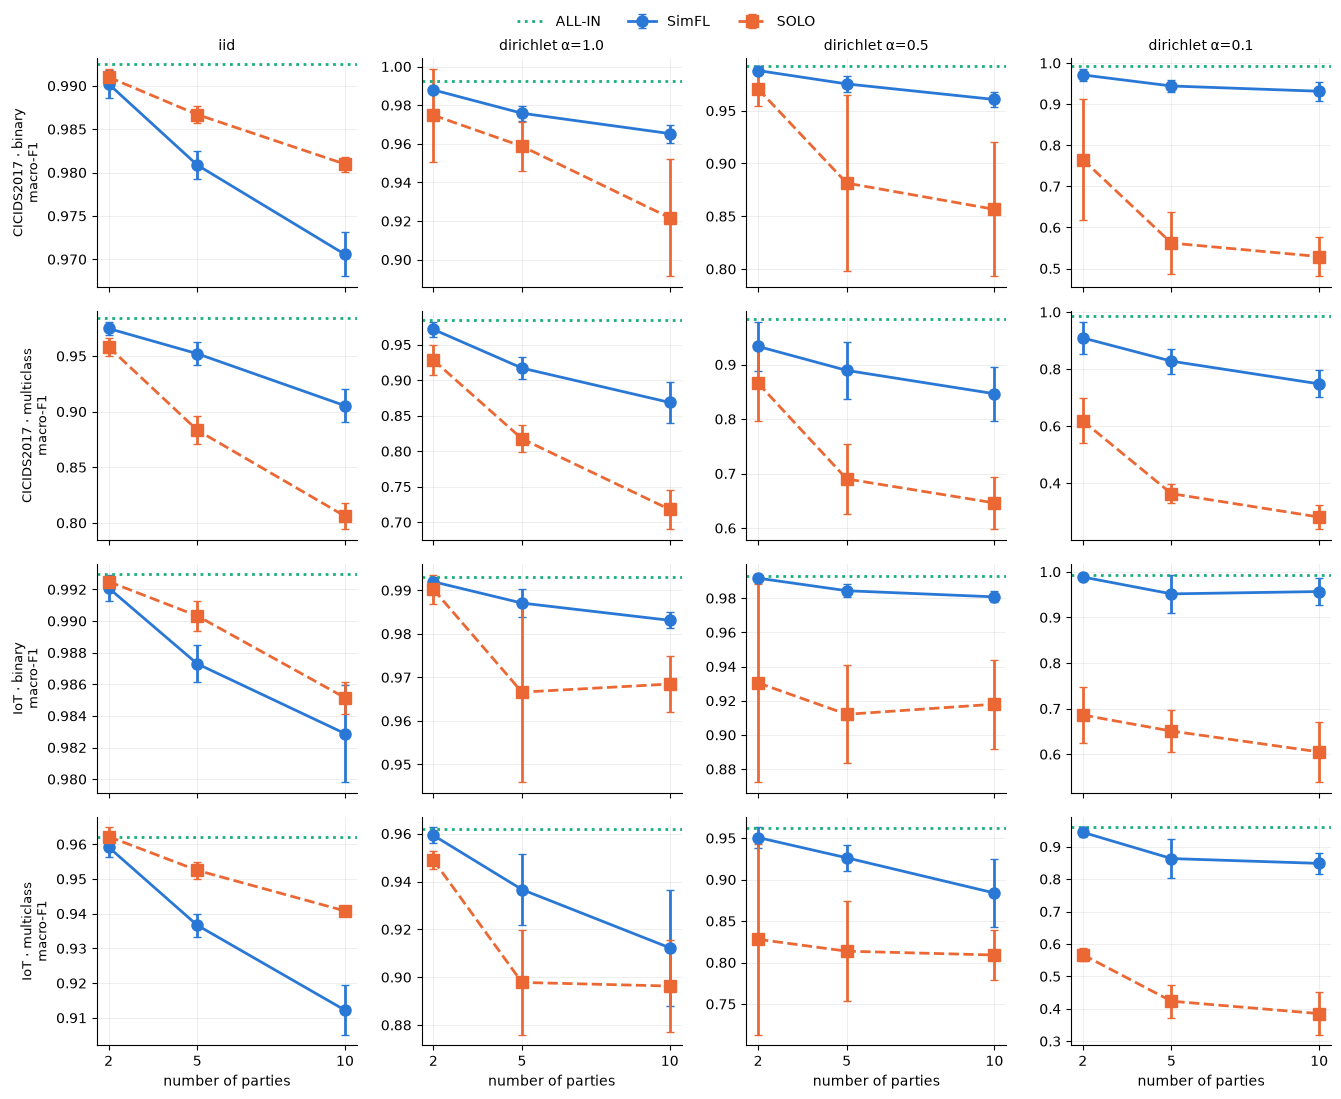

In [14]:
import matplotlib.pyplot as plt

STYLE = {"SimFL": dict(color="#2a78d6", marker="o", ls="-"),
         "SOLO": dict(color="#eb6834", marker="s", ls="--"),
         "ALL-IN": dict(color="#1baf7a", marker=None, ls=":")}
settings = [s for s in ["iid", "dirichlet α=1.0", "dirichlet α=0.5", "dirichlet α=0.1"] if s in set(runs["setting"])]
panels = [(d, m) for d in runs["dataset"].unique() for m in CONFIG["modes"]]


def plot_metric(col, ylabel, methods=("SimFL", "SOLO", "ALL-IN"), logy=False):
    fig, axes = plt.subplots(len(panels), len(settings), figsize=(3.4 * len(settings), 2.7 * len(panels)),
                             sharex=True, squeeze=False)
    for r, (d, m) in enumerate(panels):
        sub = runs[(runs["dataset"] == d) & (runs["mode"] == m)]
        for c, s in enumerate(settings):
            ax = axes[r, c]
            for meth in methods:
                if meth == "ALL-IN":
                    v = sub[sub["method"] == "ALL-IN"][col]
                    if len(v):
                        ax.axhline(v.mean(), lw=2, label="ALL-IN", **{k: STYLE[meth][k] for k in ("color", "ls")})
                    continue
                g = sub[(sub["method"] == meth) & (sub["setting"] == s)].groupby("n_parties")[col].agg(["mean", "std"])
                if len(g):
                    ax.errorbar(g.index, g["mean"], yerr=g["std"].fillna(0), lw=2, ms=8, capsize=3, label=meth,
                                **STYLE[meth])
            ax.set_xticks(CONFIG["n_parties"])
            if logy: ax.set_yscale("log")
            ax.grid(alpha=0.25, lw=0.6)
            for sp_ in ("top", "right"): ax.spines[sp_].set_visible(False)
            if r == 0: ax.set_title(s, fontsize=10)
            if c == 0: ax.set_ylabel(f"{d} · {m}\n{ylabel}", fontsize=9)
            if r == len(panels) - 1: ax.set_xlabel("number of parties")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels), frameon=False, bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    return fig


fig = plot_metric("quality.macro_f1", "macro-F1")
fig.savefig(RESULTS_DIR / "macro_f1.png", dpi=130, bbox_inches="tight")
plt.show()

### Cost of federation (SimFL)

Total bytes sent (preprocessing + training) and the estimated network time, as separate charts.
SOLO and ALL-IN send nothing.

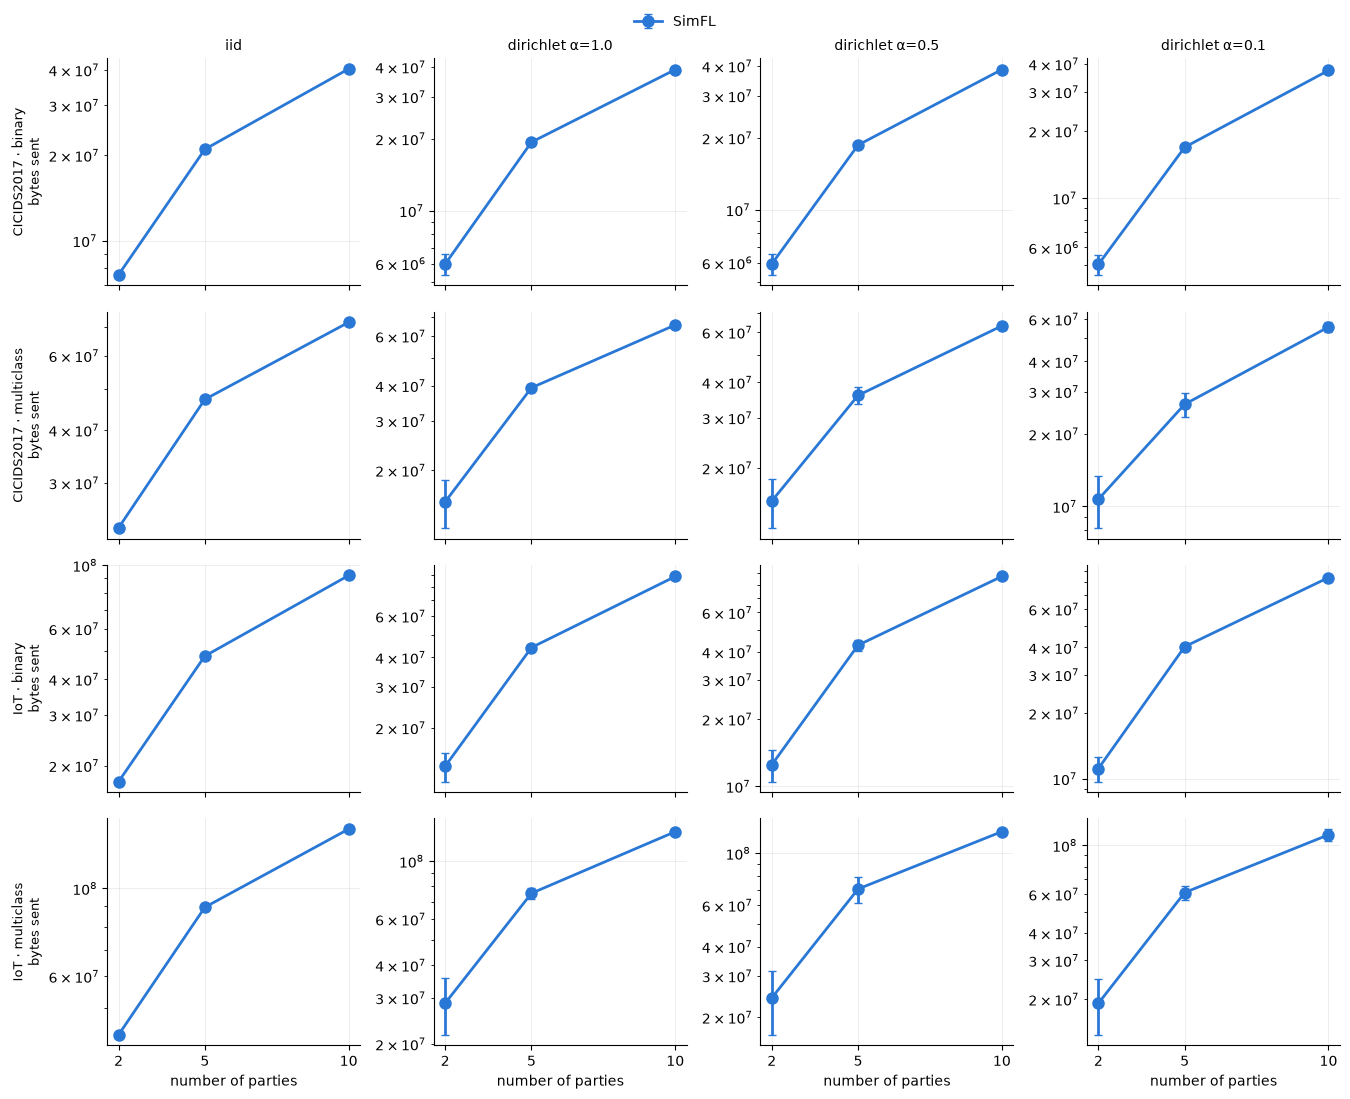

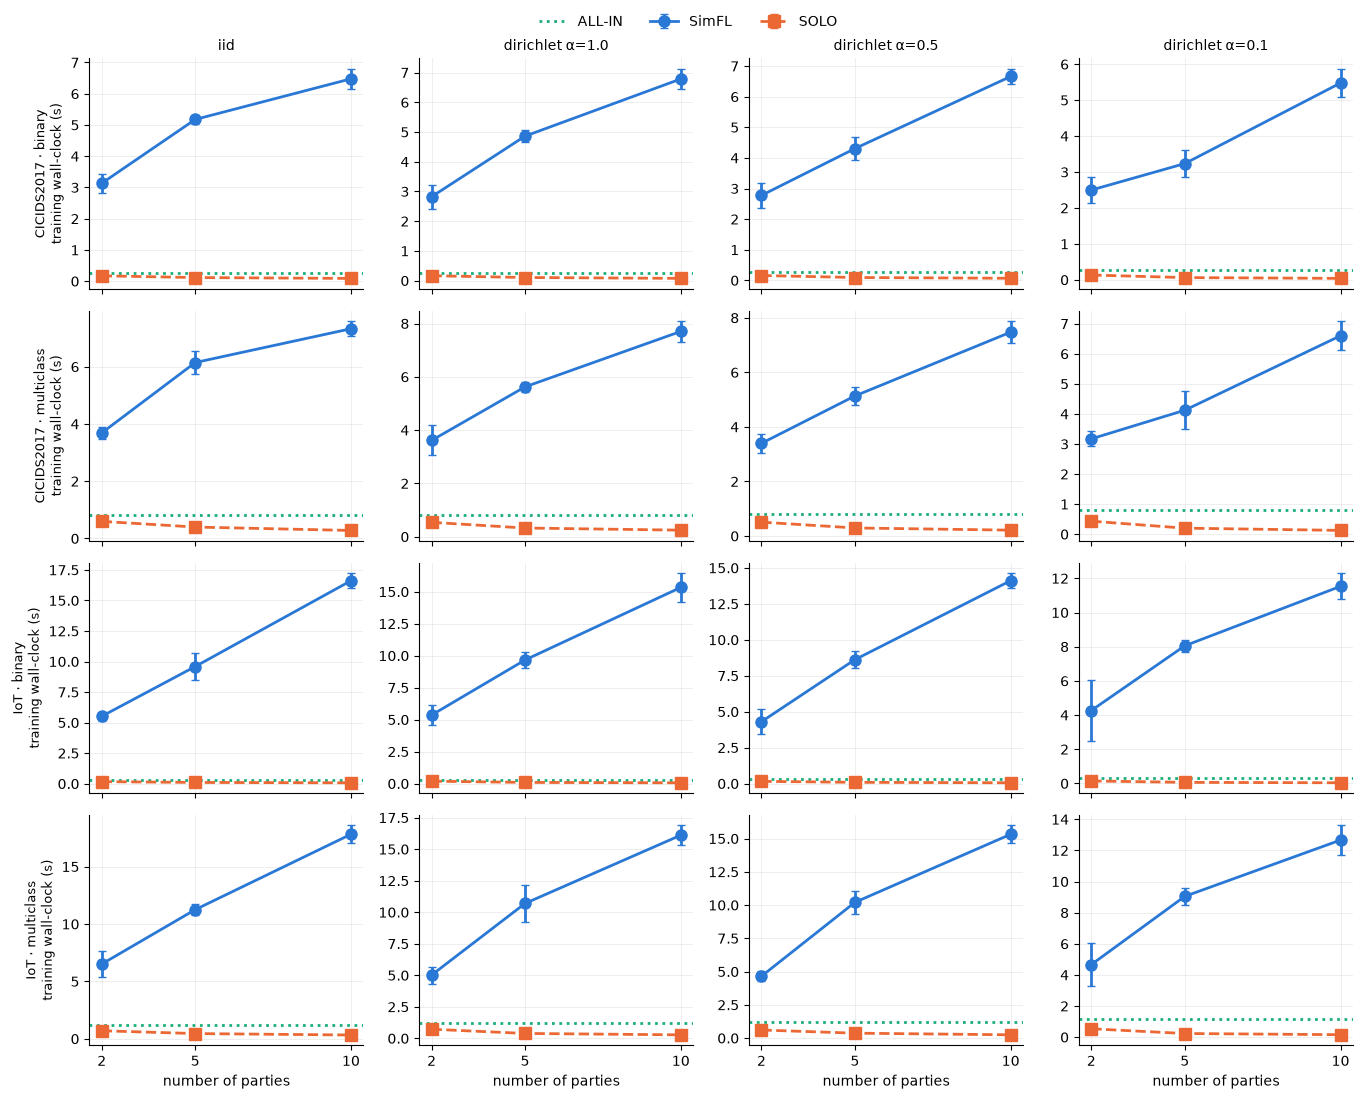

In [15]:
fig = plot_metric("communication.total_bytes", "bytes sent", methods=("SimFL",), logy=True)
fig.savefig(RESULTS_DIR / "bytes.png", dpi=130, bbox_inches="tight"); plt.show()
fig = plot_metric("timing.train_total_s", "training wall-clock (s)", methods=("SimFL", "SOLO", "ALL-IN"))
fig.savefig(RESULTS_DIR / "train_time.png", dpi=130, bbox_inches="tight"); plt.show()

In [16]:
cols = ["timing.lsh_preprocessing_s", "timing.local_gradients_s", "timing.tree_building_s",
        "timing.aggregation_comm_s", "timing.prediction_update_s", "timing.model_merge_s", "timing.train_total_s",
        "communication.preprocessing_bytes", "communication.training_bytes", "network.preprocessing_s",
        "network.training_s", "simfl.mean_matching_hashes", "simfl.unmatched_samples"]
breakdown = runs[runs["method"] == "SimFL"].groupby(["dataset", "mode", "n_parties"])[cols].mean()
breakdown.columns = [c.split(".", 1)[1] for c in cols]
with pd.option_context("display.max_columns", 30, "display.width", 250):
    display(breakdown.round(3))

lsh_preprocessing_s  local_gradients_s  tree_building_s  aggregation_comm_s  prediction_update_s  model_merge_s  train_total_s  preprocessing_bytes  training_bytes  preprocessing_s  training_s  mean_matching_hashes  \
dataset    mode       n_parties                                                                                                                                                                                                                           
CICIDS2017 binary     2                        2.239              0.009            0.350               0.058                0.115          0.026          2.808            3518640.0      2609832.35            0.321       1.209                36.505   
                      5                        3.693              0.011            0.329               0.105                0.216          0.026          4.395           14089440.0      4891917.60            1.167       1.391                34.720   
                      10                       5.462              0.013            0.328               0.158                0.344          0.026          6.351           31757040.0      7085610.25            2.581       1.567                33.885   
           multiclass 2                        2.011              0.171            0.898               0.132                0.156          0.088          3.468            3518640.0     12716063.10            0.321       2.017                36.505   
                      5                        3.697              0.175            0.804               0.223                0.250          0.088          5.257           14089440.0     23189396.60            1.167       2.855                34.720   
                      10                       5.474              0.184            0.778               0.321                0.407          0.089          7.277           31757040.0     32350325.15            2.581       3.588                33.885   
IoT        binary     2                        4.119              0.019            0.391               0.087                0.198          0.026          4.862            8212712.0      5510851.55            0.697       1.441                37.262   
                      5                        8.088              0.021            0.370               0.157                0.293          0.026          8.983           32866112.0     10986152.40            2.669       1.879                37.479   
                      10                      13.315              0.023            0.348               0.217                0.440          0.025         14.400           74005992.0     13862611.35            5.960       2.109                36.891   
           multiclass 2                        3.121              0.322            1.144               0.203                0.277          0.122          5.212            8212712.0     20459574.30            0.697       2.637                37.262   
                      5                        8.087              0.328            1.002               0.355                0.376          0.124         10.302           32866112.0     41195456.40            2.669       4.296                37.479   
                      10                      13.131              0.335            0.880               0.456                0.532          0.112         15.482           74005992.0     52417309.10            5.960       5.193                36.891   

                                 unmatched_samples  
dataset    mode       n_parties                     
CICIDS2017 binary     2                       0.00  
                      5                       0.10  
                      10                      0.55  
           multiclass 2                       0.00  
                      5                       0.10  
                      10                      0.55  
IoT        binary     2                       0.05  
                      5                  

In [17]:
# Gap closed by SimFL between SOLO (lower bound) and ALL-IN (upper bound): (SimFL - SOLO) / (ALL-IN - SOLO)
key = ["dataset", "mode", "setting", "n_parties"]
f1 = runs.groupby(key + ["method"])["quality.macro_f1"].mean().unstack("method")
allin = runs[runs["method"] == "ALL-IN"].groupby(["dataset", "mode"])["quality.macro_f1"].mean()
f1["ALL-IN"] = [allin[(d, m)] for d, m, *_ in f1.index]
f1["gap_closed"] = (f1["SimFL"] - f1["SOLO"]) / (f1["ALL-IN"] - f1["SOLO"])
display(f1.round(4))

method                                           ALL-IN    SOLO   SimFL  \
dataset    mode       setting         n_parties                           
CICIDS2017 binary     dirichlet α=0.1 2          0.9925  0.7652  0.9710   
                                      5          0.9925  0.5619  0.9441   
                                      10         0.9925  0.5291  0.9313   
                      dirichlet α=0.5 2          0.9925  0.9707  0.9881   
                                      5          0.9925  0.8814  0.9754   
                                      10         0.9925  0.8565  0.9607   
                      dirichlet α=1.0 2          0.9925  0.9748  0.9879   
                                      5          0.9925  0.9587  0.9758   
                                      10         0.9925  0.9218  0.9653   
                      iid             2          0.9925  0.9910  0.9902   
                                      5          0.9925  0.9867  0.9809   
                                      10         0.9925  0.9810  0.9706   
                      pooled          1          0.9925     NaN     NaN   
           multiclass dirichlet α=0.1 2          0.9843  0.6183  0.9092   
                                      5          0.9843  0.3631  0.8277   
                                      10         0.9843  0.2810  0.7480   
                      dirichlet α=0.5 2          0.9843  0.8657  0.9333   
                                      5          0.9843  0.6902  0.8893   
                                      10         0.9843  0.6462  0.8464   
                      dirichlet α=1.0 2          0.9843  0.9284  0.9716   
                                      5          0.9843  0.8175  0.9171   
                                      10         0.9843  0.7180  0.8687   
                      iid             2          0.9843  0.9581  0.9747   
                                      5          0.9843  0.8834  0.9521   
                                      10         0.9843  0.8061  0.9053   
                      pooled          1          0.9843     NaN     NaN   
IoT        binary     dirichlet α=0.1 2          0.9930  0.6860  0.9885   
                                      5          0.9930  0.6509  0.9515   
                                      10         0.9930  0.6052  0.9567   
                      dirichlet α=0.5 2          0.9930  0.9305  0.9917   
                                      5          0.9930  0.9121  0.9844   
                                      10         0.9930  0.9180  0.9808   
                      dirichlet α=1.0 2          0.9930  0.9902  0.9920   
                                      5          0.9930  0.9666  0.9871   
                                      10         0.9930  0.9685  0.9831   
                      iid             2          0.9930  0.9925  0.9921   
                                      5          0.9930  0.9903  0.9873   
                                      10         0.9930  0.9852  0.9829   
                      pooled          1          0.9930     NaN     NaN   
           multiclass dirichlet α=0.1 2          0.9621  0.5668  0.9444   
                                      5          0.9621  0.4234  0.8633   
                                      10         0.9621  0.3850  0.8485   
                      dirichlet α=0.5 2          0.9621  0.8280  0.9507   
                                      5          0.9621  0.8137  0.9263   
                                      10         0.9621  0.8091  0.8838   
                      dirichlet α=1.0 2          0.9621  0.9490  0.9593   
                                      5          0.9621  0.8978  0.9367   
                                      10         0.9621  0.8963  0.9123   
                      iid             2          0.9621  0.9622  0.9592   
                                      5          0.9621  0.9525  0.9367   
                                      10         0.9621  0.9408  0.9122   
                      poo


## 12. Discussion of the results (5 seeds; 50 rounds, depth 8, η = 0.1)

* **SimFL shows the gain the paper reports where it matters, on skewed data.** Under Dirichlet splits, SimFL recovers
  most of the gap between SOLO and ALL-IN. For example, CICIDS2017 multi-class with α=0.1 and 10 parties: SOLO 0.28, SimFL 0.75,
  ALL-IN 0.98 macro-F1. IoT binary with α=0.1 and 2 parties: SOLO 0.69, SimFL 0.99, ALL-IN 0.99.
  Its false-positive rate on benign traffic stays close to ALL-IN, while SOLO's is roughly 10× higher.
* **Under IID splits, SimFL is about equal to SOLO, and in a few cells slightly worse** (e.g. IoT multi-class, 10 parties: 0.912 vs 0.941).
  When each party already holds a representative sample, borrowing gradients through approximate (LSH) neighbours adds
  noise without adding information. WGB is also an approximation: the builder only sees *its own* sample positions.
* **SimFL degrades as parties increase.** Each tree is grown on one party's 1/M of the data, carrying the weight of the
  other parties' gradients, so split candidates become coarser and the approximation error grows.
* **Costs.** Preprocessing traffic grows roughly as O(M·N·L) because every party receives every other party's hashes,
  and it dominates the bytes for binary tasks. Training traffic is one aggregated-gradient message per party plus one
  tree broadcast per round, scaled by K for multi-class. Training wall-clock is dominated by LSH preprocessing, not by
  tree building. Model size and single-sample latency (~0.15–0.2 ms) are essentially the same as ALL-IN's, because the
  final model is an ordinary XGBoost ensemble of the same shape.
* ALL-IN has zero std across seeds because hist XGBoost without subsampling is deterministic, and the test split is fixed.
